In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import random

from ISLP import load_data
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage

seed = 1672

In [2]:
Boston = load_data('Boston')
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


## Initial Data Exploration

In [3]:
Boston.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
lstat      float64
medv       float64
dtype: object

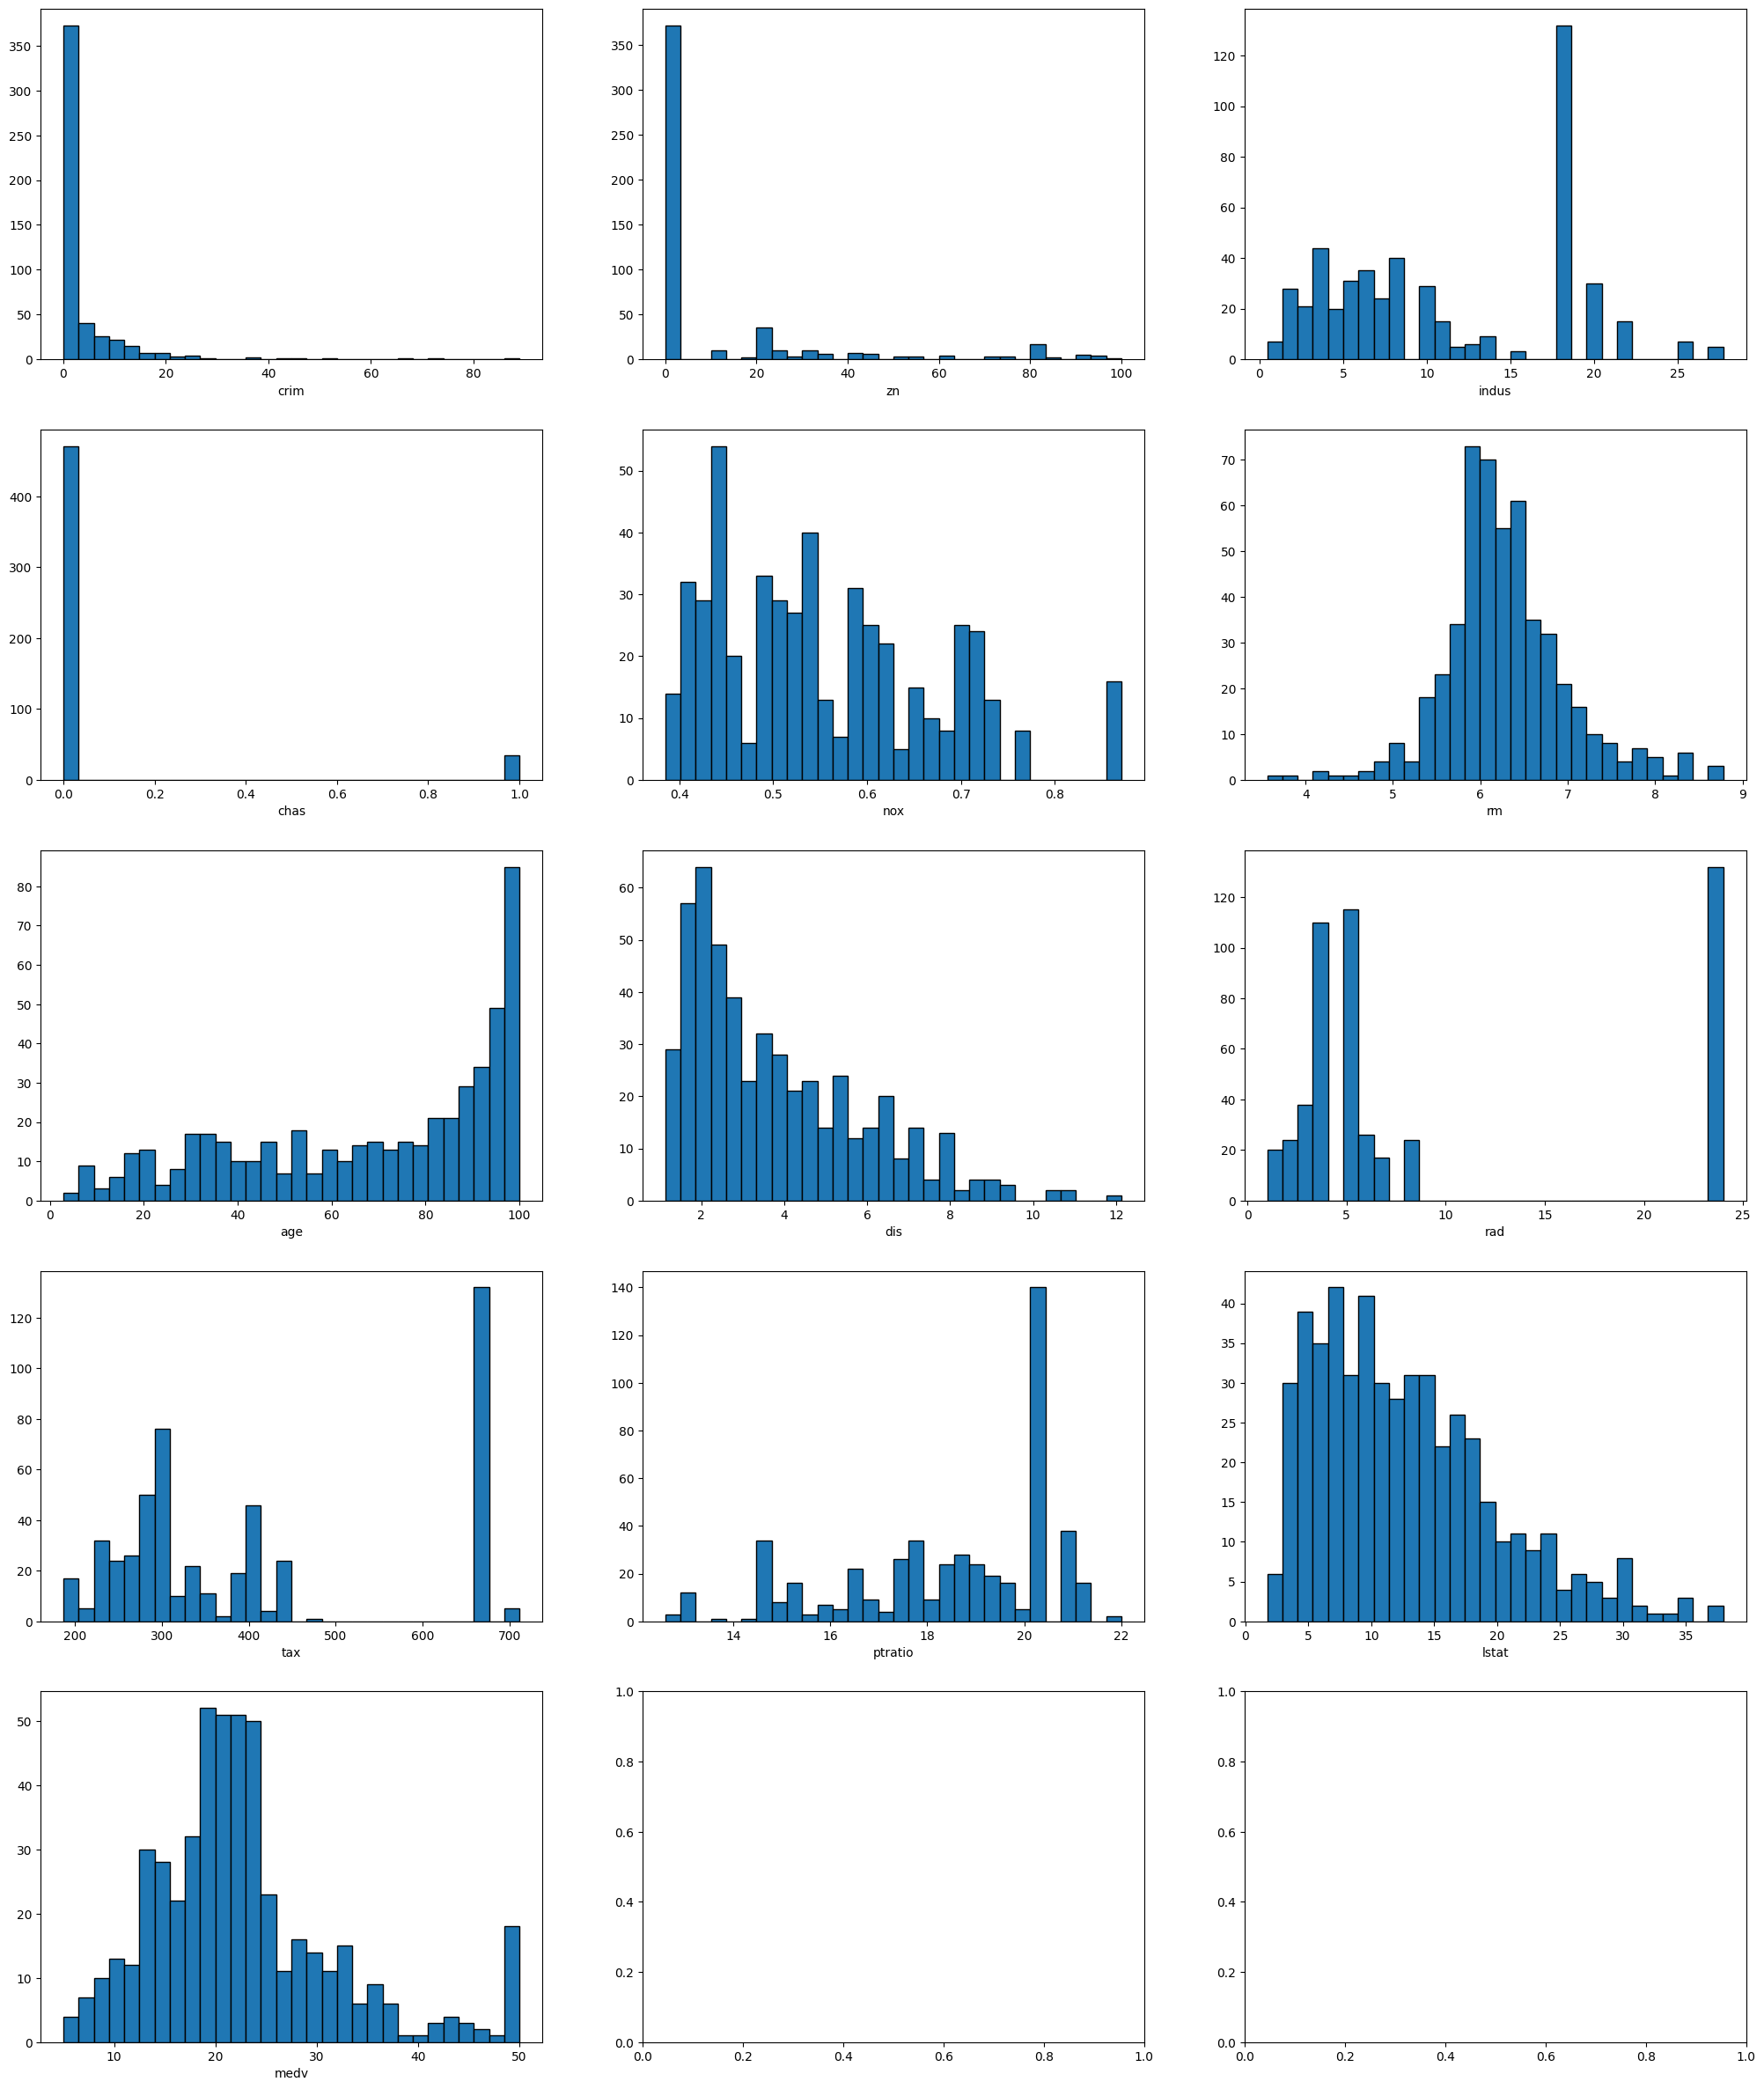

In [4]:
# Initialize the plots before drawing them
nrows = 5
ncols = 3
figsize = (5*nrows, 10*ncols)

fig, axes = subplots(nrows=nrows,
                     ncols=ncols,
                     figsize=figsize)

# Assign a grid location to each index
def range_to_grid(i, nrows, ncols):
    x=[]
    y=[]
    for n in range(nrows*ncols):
        x.append(n // ncols)
        y.append(n % ncols)
        # print(n,x[n],y[n]) # for testing this function
    return x[i],y[i]

# Plot the variables as paired boxplots
for j, col in enumerate(Boston.columns):
    r, c = range_to_grid(j, nrows, ncols)
    ax = axes[r, c]

    ax.hist(Boston[col], bins=30, edgecolor='black')

    ax.set_xlabel(col)

In [5]:
Boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


## Standardization

In [6]:
scaler = StandardScaler().set_output(transform="pandas")
Boston_std = scaler.fit_transform(Boston)
pd.DataFrame(Boston_std)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,-1.026501,1.487503
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,-0.413229,-0.487722,0.115738,-0.272599,0.158124,0.439316,0.018673,-0.625796,-0.982843,-0.803212,1.176466,-0.418147,-0.014454
502,-0.415249,-0.487722,0.115738,-0.272599,0.158124,-0.234548,0.288933,-0.716639,-0.982843,-0.803212,1.176466,-0.500850,-0.210362
503,-0.413447,-0.487722,0.115738,-0.272599,0.158124,0.984960,0.797449,-0.773684,-0.982843,-0.803212,1.176466,-0.983048,0.148802
504,-0.407764,-0.487722,0.115738,-0.272599,0.158124,0.725672,0.736996,-0.668437,-0.982843,-0.803212,1.176466,-0.865302,-0.057989


## PCA

### First we'll conduct PCA on only three of the columns.

In [7]:
subset1 = Boston_std[['age', 'nox', 'ptratio']]

### Notice that `age` and `nox` are highly correlated, but `ptratio` is as not strongly correlated with either of them.

In [8]:
pd.DataFrame(subset1.corr())

,age,nox,ptratio
age,1.000000,0.731470,0.261515
nox,0.731470,1.000000,0.188933
ptratio,0.261515,0.188933,1.000000


### Fit the principal components.

In [9]:
PCA_subset = PCA()
PCA_subset.fit(subset1)

PCA()

### When we print the components by each variable, we can see that the first (0th) component is influenced by `age` and `nox` while the second (1st) component is mostly influenced by `ptratio`. 

This is consistent with the correlations that we calculated earlier.

In [10]:
components_subset = pd.DataFrame(PCA_subset.components_, columns=subset1.columns.to_list())
components_subset

,age,nox,ptratio
0,0.670084,0.653978,0.351140
1,-0.193164,-0.303124,0.933168
2,0.716711,-0.693129,-0.076794


### What percent of variance is explained by each component?

In [11]:
PCA_subset.explained_variance_ratio_

array([0.61697612, 0.29483176, 0.08819212])

### Next we'll tranform the original data to the principal components and graph the records along first two components.

In [12]:
PCA_subset_scores = PCA_subset.transform(subset1)

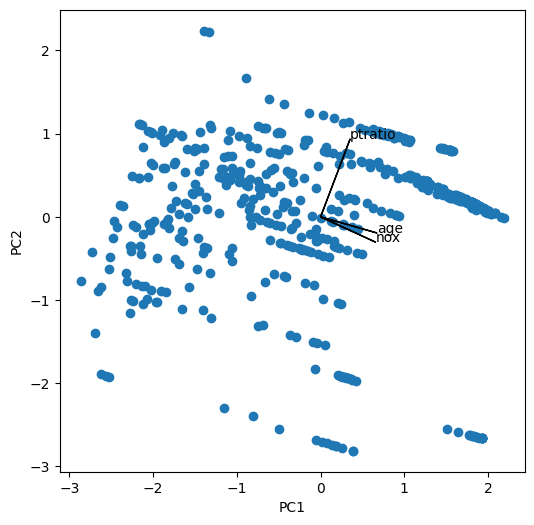

In [13]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(PCA_subset_scores[:,0], PCA_subset_scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(PCA_subset.components_.shape[1]):
    ax.arrow(0, 0, PCA_subset.components_[i,k], PCA_subset.components_[j,k])
    ax.text(PCA_subset.components_[i,k],
            PCA_subset.components_[j,k],
            subset1.columns[k])

### Now conduct principal components analysis on the entire standardized Boston dataset.

In [14]:
PCA_Boston = PCA()
PCA_Boston.fit(Boston_std)

PCA()

### Calculate the components and include the column names

In [15]:
components_Boston = pd.DataFrame(PCA_Boston.components_, columns=Boston_std.columns.to_list())

### Based on these components, determine which variable has the _most_ influence on the first principal component, and which variable has the _least_ influence on the first principal component. 

Note that the first principal component will appear as component 0

In [16]:
first_pc = components_Boston.iloc[0].abs()
var_most_influencing_1st_pc = first_pc.idxmax()
var_least_influencing_1st_pc = first_pc.idxmin()

## K-means Clustering

### First we'll conduct k-means clustering using only two variables, so that we can graph the results in 2 dimensions.

In [17]:
# create the dataset
subset2 = Boston_std[['rm', 'indus']]

In [18]:
# build the clusters
kmeans1 = KMeans(n_clusters=3,
                random_state=seed,
                n_init=1).fit(subset2)

In [19]:
# record the cluster assignments
cluster_km1 = pd.DataFrame(kmeans1.labels_)
cluster_km1

,0
0,0
1,0
2,0
3,0
4,0
...,...
501,2
502,2
503,2
504,2


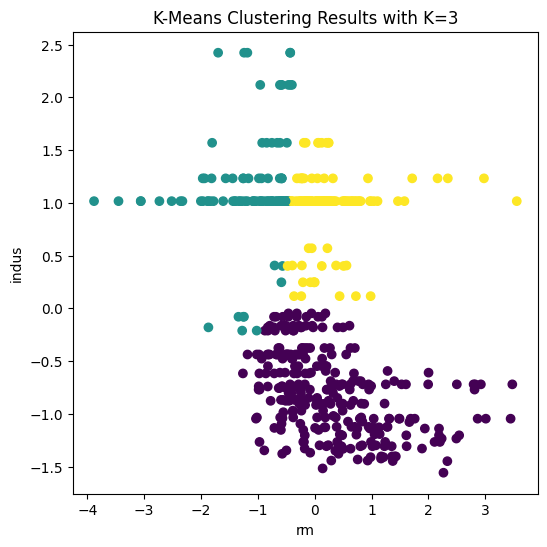

In [20]:
# plot the clusters
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km1)
ax.set_title("K-Means Clustering Results with K=3")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### Let's try this again, but choosing the optimal cluster assignments across 1000 iterations.

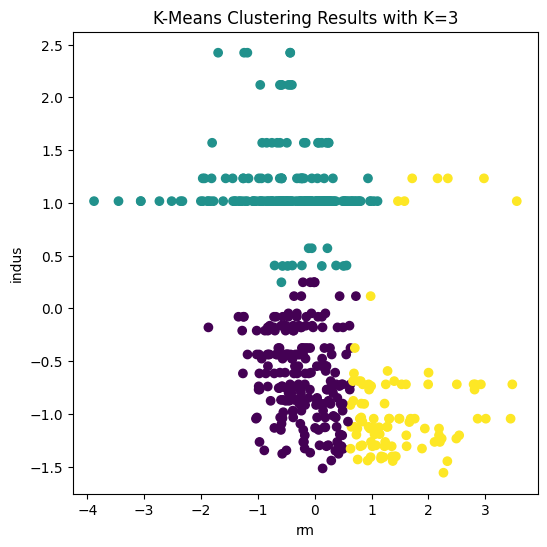

In [21]:
kmeans2 = KMeans(n_clusters=3,
                random_state=seed,
                n_init=1000).fit(subset2)

cluster_km2 = pd.DataFrame(kmeans2.labels_)

fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km2)
ax.set_title("K-Means Clustering Results with K=3")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### Now let's try 4 clusters instead of 3

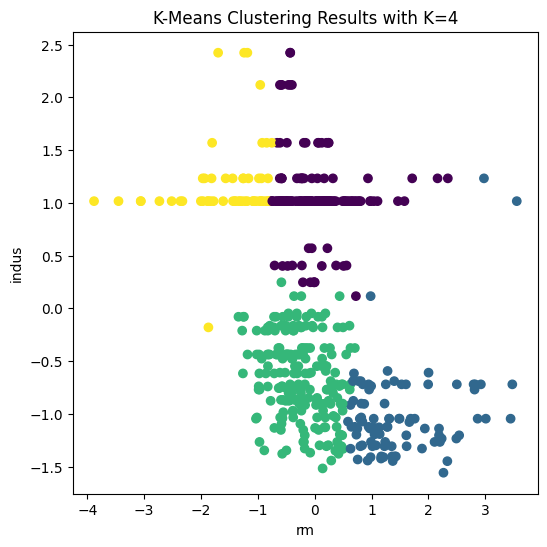

In [22]:
kmeans3 = KMeans(n_clusters=4,
                random_state=seed,
                n_init=1000).fit(subset2)

cluster_km3 = pd.DataFrame(kmeans3.labels_)

fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km3)
ax.set_title("K-Means Clustering Results with K=4")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### In the picture displaying 4 clusters (above), there are several points that are classified into one cluster but seem much closer to the centroid of another cluster. Why is that?

Because K-means minimizes total within-cluster variance rather than assigning points based solely on visual proximity in the plot, some points may appear closer to another cluster’s centroid but are assigned differently.

### Now run a K-means analysis on the entire standardized Boston dataset (with all variables included). Use 5 clusters, 1000 iterations, and the same seed as prior K-means models.

### Store the model as "kmeans_all" and the cluster assignments as "cluster_km_all"

In [23]:
kmeans_all = KMeans(n_clusters=5, random_state=seed, n_init=1000).fit(Boston_std)

cluster_km_all = pd.DataFrame(kmeans_all.labels_)

### What variable in the Boston dataset is most correlated with the cluster assignments of "kmeans_all"? 

In [24]:
corrs = Boston_std.copy()
corrs['cluster'] = cluster_km_all

correlation_values = corrs.corr()['cluster'].drop('cluster').abs()

var_most_correlated_w_kmeans = correlation_values.idxmax()


In [ ]:
# provide answer here, with variable name inside the quotes
var_most_correlated_w_kmeans = 'chas'

## Hierarchical Clustering

### To better visualize this, let's do a first example on subset of _rows_ of the Boston data. 

In [26]:
# Create a random sample by randomly choosing row indices
random.seed(seed)
index = random.sample(range(Boston_std.shape[0]), 12)

subset3 = Boston_std.iloc[index]
subset3

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
275,-0.409341,1.229060,-0.689681,-0.272599,-0.930305,0.811152,-0.916570,0.224497,-0.637962,-0.916058,-0.395567,-1.355910,1.030385
144,-0.097030,-0.487722,1.231945,-0.272599,2.732346,-1.968357,1.039261,-1.164247,-0.523001,-0.031105,-1.736418,2.332062,-1.168132
105,-0.405084,-0.487722,-0.375976,-0.272599,-0.299707,-0.617781,1.000145,-0.802491,-0.523001,-0.143951,1.130230,0.535034,-0.330083
259,-0.344101,0.370669,-1.045700,-0.272599,0.797361,0.794056,1.117494,-0.848221,-0.523001,-0.856665,-2.522434,-0.806429,0.823594
272,-0.407181,0.370669,-0.609431,-0.272599,-0.783454,0.360960,-0.351157,0.058212,-0.752922,-1.100176,0.066796,-0.690084,0.203221
385,1.535926,-0.487722,1.015999,-0.272599,1.255192,-1.435535,1.049929,-1.126122,1.661245,1.530926,0.806576,2.545127,-1.668784
16,-0.297868,-0.487722,-0.437258,-0.272599,-0.144217,-0.498110,-1.396638,0.334449,-0.637962,-0.601276,1.176466,-0.851284,0.061732
9,-0.400729,0.048772,-0.476654,-0.272599,-0.265154,-0.399808,0.616090,1.329635,-0.523001,-0.577519,-1.505237,0.623344,-0.395385
265,-0.331885,0.370669,-1.045700,-0.272599,0.797361,-1.032357,-0.205359,-0.859725,-0.523001,-0.856665,-2.522434,-0.308812,0.029081
41,-0.405687,-0.487722,-0.616727,-0.272599,-0.921667,0.691480,-2.335437,0.915493,-0.752922,-1.040783,-0.256858,-1.095187,0.442663


### We'll use complete linkage for the clustering

In [27]:
HClust1 = AgglomerativeClustering
hc_comp = HClust1(distance_threshold=0,
                  n_clusters=None,
                  linkage='complete')
hc_comp.fit(subset3)

AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

### We can create a dendrogram, too.

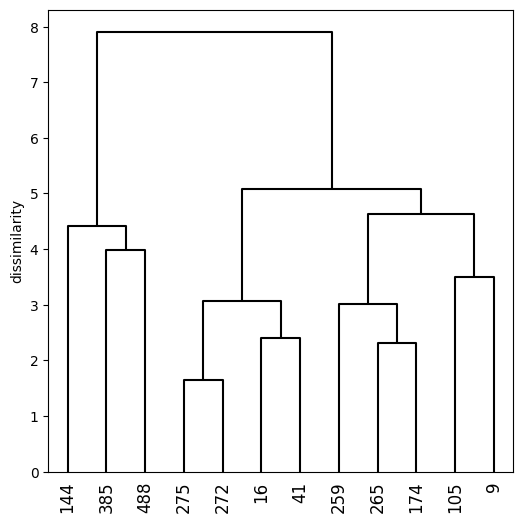

In [28]:
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=-np.inf,
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### We can even add color to the dendrogram to distinguish between colors.

Note that we specify a dissimilarity threshold (based on the linkage choice) in this function, rather than a number of clusters.

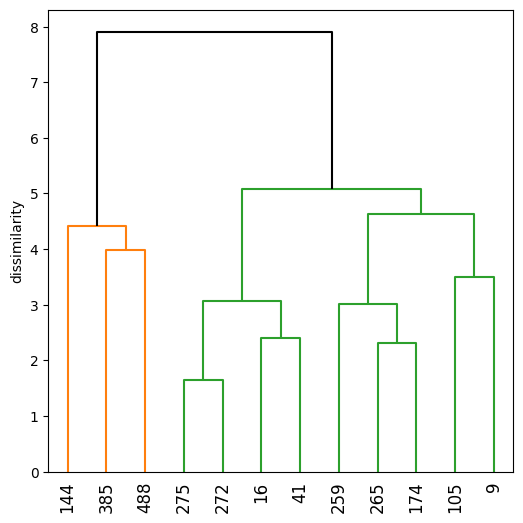

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=6, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### We can also store the cluster assignments.

In [30]:
cluster_h1 = cut_tree(linkage_comp, n_clusters=2)
cluster_h1

array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0]])

### Without changing the underlying model, we can create 3 (or more) clusters instead of 2.

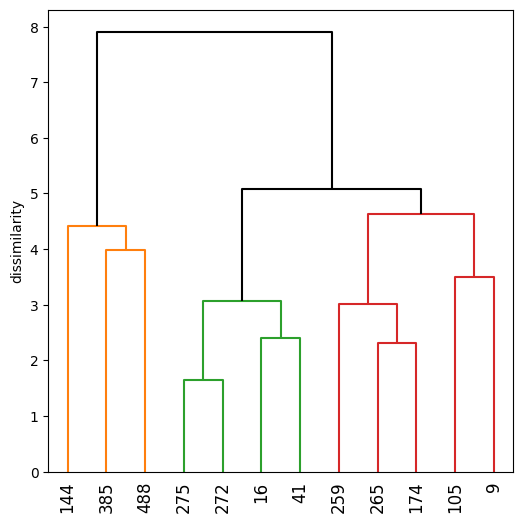

In [31]:
cluster_h2 = cut_tree(linkage_comp, n_clusters=3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=4.75, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### Let's try doing hierarchical clustering with _average_ linkage.

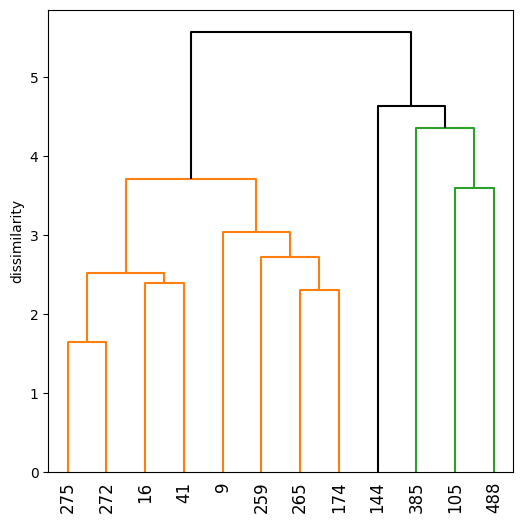

In [32]:
hc_avg = HClust1(distance_threshold=0,
                  n_clusters=None,
                  linkage='average')
hc_avg.fit(subset3)

linkage_avg = compute_linkage(hc_avg)
cluster_h3 = cut_tree(linkage_avg, n_clusters=3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_avg,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=4.45, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### Now run hierarchical clustering with complete linkage on the entire standardized Boston dataset (with all records included). 

### Use 5 clusters and store the cluster assignments as "cluster_h_all"

In [33]:
hc_all = AgglomerativeClustering(n_clusters=5, linkage='complete')
hc_all.fit(Boston_std)

cluster_h_all = pd.DataFrame(hc_all.labels_)


### Using the cluster assignments in `cluster_h_all`, how many records of the Boston data are in the largest cluster? How about the smallest cluster? 

In [34]:
counts = cluster_h_all[0].value_counts()

records_in_largest_cluster = counts.max()
records_in_smallest_cluster = counts.min()


In [35]:
# provide answers here. Do not enter these numbers as strings (i.e., not in quotes)
records_in_largest_cluster = counts.max()
records_in_smallest_cluster = counts.min()

### Why did we complete the analysis in this notebook without creating train and test sets?

Because clustering is unsupervised and does not involve predicting labels, we use the full dataset to discover patterns rather than splitting into train and test sets.